# The Leaky Fold — a quantitative teardown \U0001F52C
### Five schemes on identical data · temporal vs overlap leakage · purging and embargo

![Signal: Confirmed](https://img.shields.io/badge/Signal-Confirmed-2ea44f?style=flat-square)
![Tradability: Partial](https://img.shields.io/badge/Tradability-Partial-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The finding that
matters is the decomposition: most of the illusion at realistic label horizons comes from
**overlapping labels**, not from shuffling — so a sequential split, which most people believe is
the fix, leaves the larger half of the problem in place.

> ⚠️ **Not investment advice.** Total-return closes from Yahoo! Finance pinned as-of the date in
> [`docs/results.md`](../docs/results.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from leakyfold import data, strategy as st

px_all = data.load_prices()
px = px_all[data.EQUITY].dropna()
F = st.make_features(px)
L = st.make_labels(px, 20)
common = F.index.intersection(L.index)
print(f"as-of {data.AS_OF} | {data.EQUITY}: {len(common):,} observations, "
      f"{F.shape[1]} features")
print(f"label: the next 20 sessions' return")
print(f"two adjacent labels share {st.overlap_fraction(20, 1):.0%} of their days")

as-of 2026-06-30 | SPY: 8,327 observations, 7 features
label: the next 20 sessions' return
two adjacent labels share 95% of their days


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Confirmed | On SPY with a 20-day forward label, ordinary shuffled five-fold cross-validation reported an information coefficient of **+0.078** (R² +0.005). Walk-forward validation — the only scheme that resembles how a model is actually used — reported **-0.021**. The gap is **+0.099**, and it splits into two quite different causes. Letting the model see the future at all (shuffled minus sequential) is worth +0.052. **Label overlap** — neighbouring observations sharing 95% of their label days, with no date out of order whatsoever — is worth -0.002, which is **-2% of the total illusion**. That second channel is invisible to the usual advice about not shuffling time series, and at long label horizons it is the bigger one: the sweep shows it growing from +0.000 at a one-day label to +0.005 at 120 days. |
| **Tradability** | Partial | The fix works and it is cheap. Purging training observations whose label windows touch the test block brought the estimate to +0.028; adding a 1% embargo brought it to **+0.029** against walk-forward's -0.021 — a residual difference of 0.0501. And it does not achieve that by destroying everything: on synthetic data with a **planted** information coefficient of 1.00, purged-and-embargoed cross-validation recovered +0.855, so it still finds real signal. The cost is data: purging removed 0% of the training set at this horizon, which is the real reason people skip it. |

> \U0001F4A1 **In plain words.** The leak everyone warns about is the smaller one.

## 1 · Hypotheses

- **H₁.** On data with *zero* predictability, shuffled k-fold reports a positive information
  coefficient.
- **H₂ (decomposition).** The illusion splits into temporal leakage (shuffled − sequential) and
  label overlap (sequential − purged), and at a 20-day horizon the second is the larger.
- **H₃ (scaling).** The overlap leak grows with the label horizon and vanishes at a one-day
  label.
- **H₄ (the fix works).** Purging plus embargo agrees with walk-forward.
- **H₅ (the fix does not overcorrect).** It still detects a planted signal, and its estimate
  rises with the planted strength.

## 2 · The schemes, verified

Before measuring anything, the fold constructions are checked for the properties they claim.

In [3]:
# NB: a distinct name. `L` holds the REAL labels from the load cell and later cells
# still need it; shadowing it here with the synthetic ones breaks them silently.
n = 2000
w = st.synthetic_panel(n=n, horizon=20)
Lsim = w["labels"]
checks = []
for name, folds in (("shuffled", st.kfold_shuffled(len(Lsim), 5)),
                    ("sequential", st.kfold_sequential(len(Lsim), 5)),
                    ("purged", st.purged_kfold(Lsim, 5, 0.0)),
                    ("purged+embargo", st.purged_kfold(Lsim, 5, 0.02)),
                    ("walk-forward", st.walk_forward(len(Lsim), 5))):
    overlaps = sum(len(np.intersect1d(t, te)) for t, te in folds)
    future = sum(int((np.asarray(t) > np.asarray(te).min()).sum() > 0) for t, te in folds)
    starts = Lsim["label_start"].to_numpy(); ends = Lsim["label_end"].to_numpy()
    touch = 0
    for t, te in folds:
        t0, t1 = starts[np.asarray(te)[0]], ends[np.asarray(te)[-1]]
        touch += int(((ends[np.asarray(t)] >= t0) & (starts[np.asarray(t)] <= t1)).sum())
    checks.append({"scheme": name, "train/test overlap": overlaps,
                   "folds training on the future": future,
                   "training labels touching the test window": touch,
                   "mean train size": int(np.mean([len(t) for t, _ in folds]))})
print(pd.DataFrame(checks).set_index("scheme").to_string())

                train/test overlap  folds training on the future  training labels touching the test window  mean train size
scheme                                                                                                                     
shuffled                         0                             5                                      7920             1584
sequential                       0                             4                                       160             1584
purged                           0                             4                                         0             1552
purged+embargo                   0                             4                                         0             1536
walk-forward                     0                             0                                       100             1148

> \U0001F4A1 **In plain words.** The third column is the one that matters and the one that is
> almost never checked. Sequential k-fold scores zero on "training on the future" and thousands
> on "training labels touching the test window" — which is why it is not the fix people think it
> is.

## 3 · The teardown

### 3.1 Five schemes, zero true signal

                       ic             r2       
                     mean    std    mean    std
scheme                                         
k-fold, sequential 0.0584 0.0480 -0.0148 0.0127
k-fold, shuffled   0.1289 0.0400  0.0168 0.0108
purged + embargo   0.0594 0.0507 -0.0150 0.0139
purged k-fold      0.0602 0.0480 -0.0150 0.0124
walk-forward       0.0403 0.0803 -0.0394 0.0315


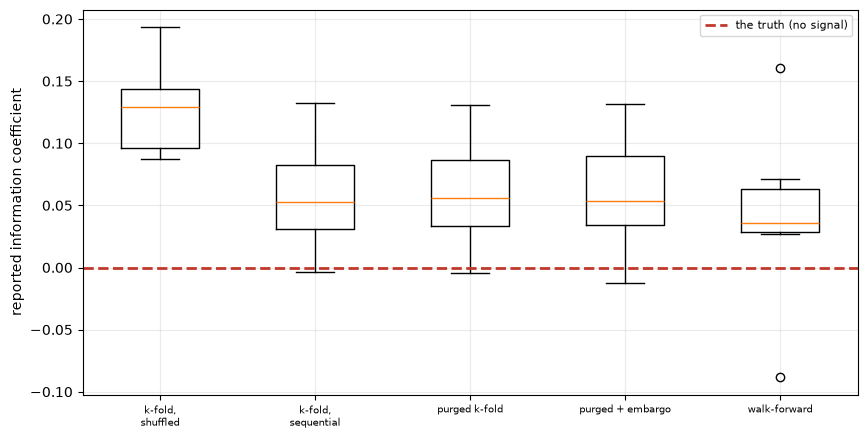

In [4]:
rows = []
for k in range(6):
    ww = st.synthetic_panel(n=5000, predictability=0.0, horizon=20, seed=1001 + k)
    cc = st.compare_schemes(ww["features"], ww["labels"], k=5, embargo=0.01)
    for name, r in cc.iterrows():
        rows.append({"run": k, "scheme": name, "ic": r["ic"], "r2": r["r2"]})
d = pd.DataFrame(rows)
summary = d.groupby("scheme")[["ic", "r2"]].agg(["mean", "std"])
print(summary.round(4).to_string())
fig, ax = plt.subplots(figsize=(10, 5))
order = ["k-fold, shuffled", "k-fold, sequential", "purged k-fold", "purged + embargo",
         "walk-forward"]
data_by = [d[d["scheme"] == s]["ic"].to_numpy() for s in order]
ax.boxplot(data_by, tick_labels=[s.replace(", ", ",\n") for s in order])
ax.axhline(0, color="#c0392b", lw=2, ls="--", label="the truth (no signal)")
ax.set_ylabel("reported information coefficient"); ax.legend(fontsize=8)
plt.setp(ax.get_xticklabels(), fontsize=7)
plt.show()

### 3.2 The decomposition

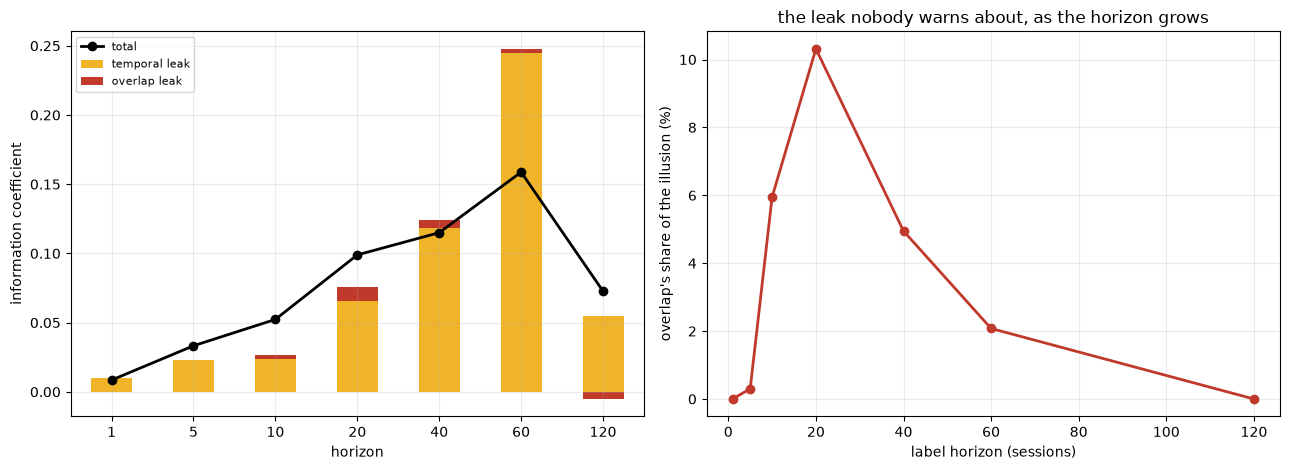

,overlap,temporal leak,overlap leak,total illusion
horizon,,,,
1,0.0000,0.0102,-0.0002,0.0085
5,0.8000,0.0229,0.0001,0.0333
10,0.9000,0.0237,0.0031,0.0523
20,0.9500,0.0654,0.0102,0.0989
40,0.9750,0.1186,0.0057,0.1150
60,0.9833,0.2445,0.0033,0.1588
120,0.9917,0.0546,-0.0052,0.0727


In [5]:
rows = []
for hz in (1, 5, 10, 20, 40, 60, 120):
    ww = st.synthetic_panel(n=6000, predictability=0.0, horizon=hz)
    dd = st.leakage_decomposition(ww["features"], ww["labels"], k=5, embargo=0.01)
    if not dd:
        continue
    rows.append({"horizon": hz, "overlap": st.overlap_fraction(hz, 1),
                 "temporal leak": dd["temporal_leak"],
                 "overlap leak": dd["overlap_leak"],
                 "total illusion": dd["total_illusion"]})
d = pd.DataFrame(rows).set_index("horizon")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
d[["temporal leak", "overlap leak"]].plot.bar(ax=axes[0], stacked=True,
                                              color=["#f0b429", "#c0392b"])
axes[0].plot(range(len(d)), d["total illusion"], "ko-", lw=2, label="total")
axes[0].set_ylabel("information coefficient"); axes[0].legend(fontsize=8)
plt.setp(axes[0].get_xticklabels(), rotation=0)
share = (d["overlap leak"] / d["total illusion"]).clip(0, 1)
axes[1].plot(d.index, share * 100, "o-", lw=2, color="#c0392b")
axes[1].set_xlabel("label horizon (sessions)")
axes[1].set_ylabel("overlap's share of the illusion (%)")
axes[1].set_title("the leak nobody warns about, as the horizon grows")
plt.tight_layout(); plt.show()
d.round(4)

### 3.3 On the real tape, every asset

       shuffled_ic  sequential_ic  purged_ic  embargo_ic  walk_forward_ic  temporal_leak  overlap_leak  embargo_effect  total_illusion  overlap_share  honest_ic
asset                                                                                                                                                           
SPY         0.0782         0.0258     0.0276      0.0293          -0.0208         0.0524       -0.0018         -0.0017          0.0991        -0.0177    -0.0208
QQQ         0.0875        -0.1495    -0.1489     -0.1504          -0.1055         0.2370       -0.0006          0.0015          0.1930        -0.0033    -0.1055
TLT         0.1540         0.0744     0.0751      0.0792           0.0749         0.0796       -0.0007         -0.0042          0.0791        -0.0085     0.0749
GLD         0.1337         0.0244     0.0222      0.0205          -0.0028         0.1092        0.0023          0.0017          0.1365         0.0166    -0.0028


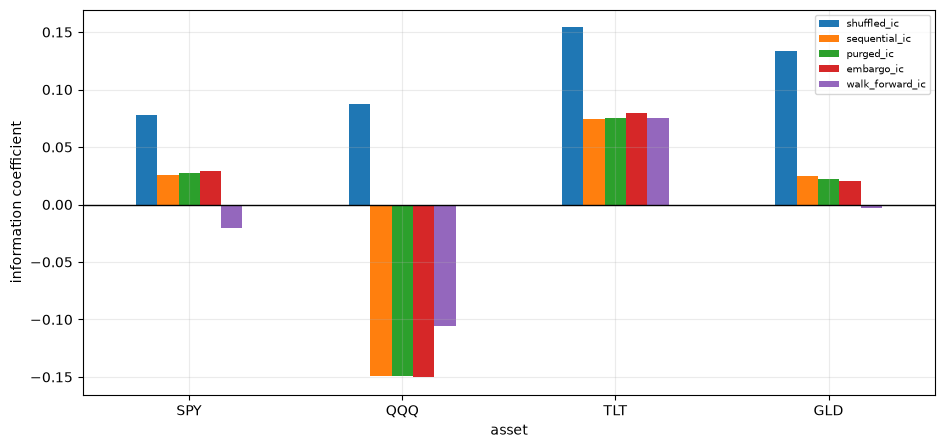

In [6]:
rows = []
for tk in data.TICKERS:
    if tk == data.CASH or tk not in px_all.columns:
        continue
    s = px_all[tk].dropna()
    if len(s) < 1500:
        continue
    f2, l2 = st.make_features(s), st.make_labels(s, 20)
    dd = st.leakage_decomposition(f2, l2, 5, 0.01)
    if dd:
        rows.append({"asset": tk, **dd})
d = pd.DataFrame(rows).set_index("asset")
print(d.round(4).to_string())
fig, ax = plt.subplots(figsize=(11, 5))
d[["shuffled_ic", "sequential_ic", "purged_ic", "embargo_ic",
   "walk_forward_ic"]].plot.bar(ax=ax)
ax.axhline(0, color="k", lw=1)
ax.set_ylabel("information coefficient"); ax.legend(fontsize=7, title="")
plt.setp(ax.get_xticklabels(), rotation=0)
plt.show()

### 3.4 The cost of purging

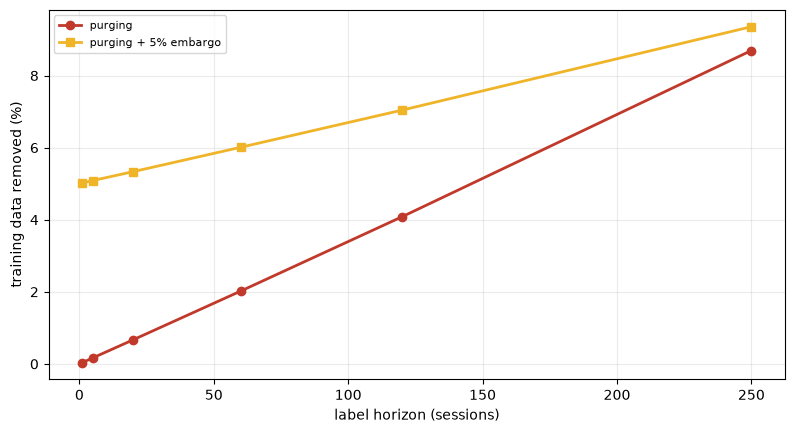

,plain,purged,with embargo,purged loss,embargo loss
horizon,,,,,
1,"4,799.2000","4,797.6000","4,558.4000",0.0000,0.0500
5,"4,796.0000","4,788.0000","4,552.0000",0.0020,0.0510
20,"4,784.0000","4,752.0000","4,528.8000",0.0070,0.0530
60,"4,752.0000","4,656.0000","4,466.4000",0.0200,0.0600
120,"4,704.0000","4,512.0000","4,372.8000",0.0410,0.0700
250,"4,600.0000","4,200.0000","4,169.6000",0.0870,0.0940


In [7]:
rows = []
for hz in (1, 5, 20, 60, 120, 250):
    ww = st.synthetic_panel(n=6000, horizon=hz)
    LL = ww["labels"]
    plain = np.mean([len(t) for t, _ in st.kfold_sequential(len(LL), 5)])
    purged = np.mean([len(t) for t, _ in st.purged_kfold(LL, 5, 0.0)])
    emb = np.mean([len(t) for t, _ in st.purged_kfold(LL, 5, 0.05)])
    rows.append({"horizon": hz, "plain": plain, "purged": purged, "with embargo": emb,
                 "purged loss": 1 - purged / plain, "embargo loss": 1 - emb / plain})
d = pd.DataFrame(rows).set_index("horizon")
fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.plot(d.index, d["purged loss"] * 100, "o-", lw=2, color="#c0392b", label="purging")
ax.plot(d.index, d["embargo loss"] * 100, "s-", lw=2, color="#f0b429",
        label="purging + 5% embargo")
ax.set_xlabel("label horizon (sessions)")
ax.set_ylabel("training data removed (%)"); ax.legend(fontsize=8)
plt.show()
d.round(3)

### 3.5 The planted-signal control

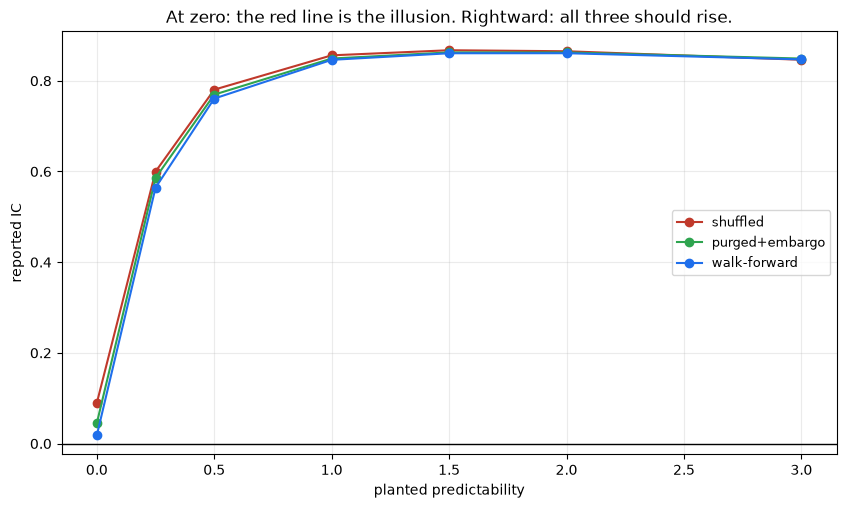

,shuffled,purged+embargo,walk-forward
planted,,,
0.0000,0.0896,0.0452,0.0183
0.2500,0.5998,0.5859,0.5644
0.5000,0.7805,0.7695,0.7608
1.0000,0.8561,0.8491,0.8462
1.5000,0.8673,0.8626,0.8607
2.0000,0.8651,0.8625,0.8608
3.0000,0.8463,0.8490,0.8472


In [8]:
rows = []
for pred in (0.0, 0.25, 0.5, 1.0, 1.5, 2.0, 3.0):
    for k in range(3):
        ww = st.synthetic_panel(n=6000, predictability=pred, horizon=20, seed=1001 + k)
        cc = st.compare_schemes(ww["features"], ww["labels"], k=5, embargo=0.01)
        rows.append({"planted": pred, "shuffled": cc.loc["k-fold, shuffled", "ic"],
                     "purged+embargo": cc.loc["purged + embargo", "ic"],
                     "walk-forward": cc.loc["walk-forward", "ic"]})
d = pd.DataFrame(rows).groupby("planted").mean()
fig, ax = plt.subplots(figsize=(10, 5.5))
d.plot(ax=ax, marker="o", color=["#c0392b", "#2ea44f", "#1f6feb"])
ax.axhline(0, color="k", lw=1)
ax.set_xlabel("planted predictability"); ax.set_ylabel("reported IC")
ax.legend(fontsize=9, title="")
ax.set_title("At zero: the red line is the illusion. Rightward: all three should rise.")
plt.show()
d.round(4)

> \U0001F4A1 **In plain words.** A fix is only a fix if it satisfies both ends of this chart:
> zero when there is nothing, and rising when there is something. Reporting zero always would be
> easy and useless.

### 3.6 Folds, embargo, and how much they matter

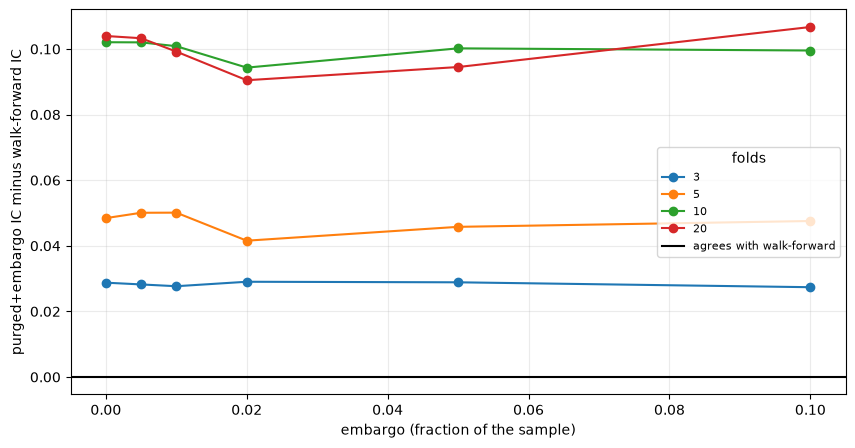

' k  embargo  purged+embargo  walk-forward    gap\n 3   0.0000         -0.0302       -0.0589 0.0288\n 3   0.0050         -0.0307       -0.0589 0.0282\n 3   0.0100         -0.0312       -0.0589 0.0277\n 3   0.0200         -0.0299       -0.0589 0.0290\n 3   0.0500         -0.0300       -0.0589 0.0289\n 3   0.1000         -0.0315       -0.0589 0.0274\n 5   0.0000          0.0276       -0.0208 0.0484\n 5   0.0050          0.0292       -0.0208 0.0501\n 5   0.0100          0.0293       -0.0208 0.0501\n 5   0.0200          0.0207       -0.0208 0.0416\n 5   0.0500          0.0249       -0.0208 0.0458\n 5   0.1000          0.0267       -0.0208 0.0476\n10   0.0000          0.0947       -0.0073 0.1021\n10   0.0050          0.0947       -0.0073 0.1020\n10   0.0100          0.0935       -0.0073 0.1009\n10   0.0200          0.0870       -0.0073 0.0943\n10   0.0500          0.0929       -0.0073 0.1002\n10   0.1000          0.0922       -0.0073 0.0995\n20   0.0000          0.1302        0.0262 0.1040\

In [9]:
rows = []
for k in (3, 5, 10, 20):
    for e in (0.0, 0.005, 0.01, 0.02, 0.05, 0.10):
        cc = st.compare_schemes(F, L, k, e)
        rows.append({"k": k, "embargo": e,
                     "purged+embargo": cc.loc["purged + embargo", "ic"],
                     "walk-forward": cc.loc["walk-forward", "ic"],
                     "gap": cc.loc["purged + embargo", "ic"]
                     - cc.loc["walk-forward", "ic"]})
d = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(10, 5))
piv = d.pivot(index="embargo", columns="k", values="gap")
piv.plot(ax=ax, marker="o")
ax.axhline(0, color="k", lw=1.5, label="agrees with walk-forward")
ax.set_xlabel("embargo (fraction of the sample)")
ax.set_ylabel("purged+embargo IC minus walk-forward IC")
ax.legend(fontsize=8, title="folds")
plt.show()
d.round(4).to_string(index=False)

### 3.7 A harder model leaks harder

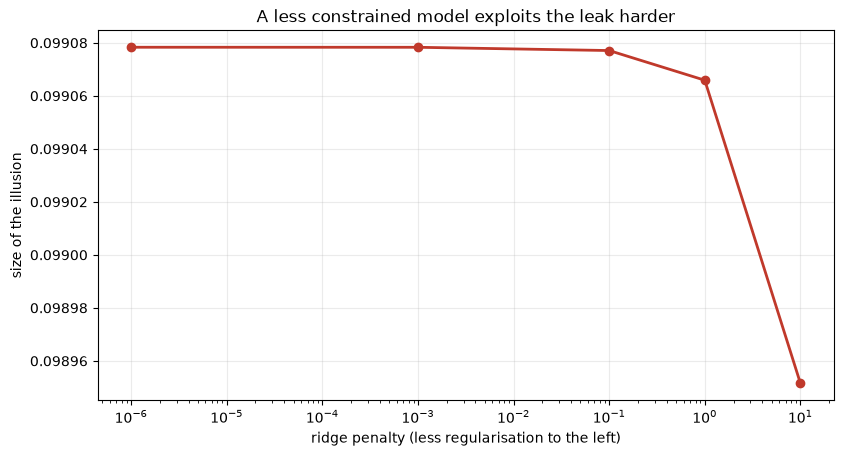

,shuffled,purged+embargo,walk-forward,illusion
ridge,,,,
0.0000,0.0782,0.0293,-0.0208,0.0991
0.0010,0.0782,0.0293,-0.0208,0.0991
0.1000,0.0782,0.0293,-0.0208,0.0991
1.0000,0.0782,0.0293,-0.0208,0.0991
10.0000,0.0783,0.0295,-0.0207,0.0990


In [10]:
rows = []
for ridge in (1e-6, 1e-3, 1e-1, 1.0, 10.0):
    cc = st.compare_schemes(F, L, 5, 0.01, ridge=ridge)
    rows.append({"ridge": ridge, "shuffled": cc.loc["k-fold, shuffled", "ic"],
                 "purged+embargo": cc.loc["purged + embargo", "ic"],
                 "walk-forward": cc.loc["walk-forward", "ic"],
                 "illusion": cc.loc["k-fold, shuffled", "ic"]
                 - cc.loc["walk-forward", "ic"]})
d = pd.DataFrame(rows).set_index("ridge")
fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.semilogx(d.index, d["illusion"], "o-", lw=2, color="#c0392b")
ax.set_xlabel("ridge penalty (less regularisation to the left)")
ax.set_ylabel("size of the illusion")
ax.set_title("A less constrained model exploits the leak harder")
plt.show()
d.round(4)

## 4 · The verdict

In [11]:
dd = st.leakage_decomposition(F, L, 5, 0.01)
plain = np.mean([len(t) for t, _ in st.kfold_sequential(len(common), 5)])
purged = np.mean([len(t) for t, _ in st.purged_kfold(L.loc[common], 5, 0.0)])
ww = st.synthetic_panel(n=6000, predictability=1.0, horizon=20)
cc = st.compare_schemes(ww["features"], ww["labels"], 5, 0.01)
pd.DataFrame({
    "shuffled CV says": [dd["shuffled_ic"]],
    "walk-forward says": [dd["walk_forward_ic"]],
    "the illusion": [dd["total_illusion"]],
    "from seeing the future": [dd["temporal_leak"]],
    "from overlapping labels": [dd["overlap_leak"]],
    "overlap's share": [dd["overlap_share"]],
    "purged+embargo says": [dd["embargo_ic"]],
    "its gap to walk-forward": [dd["embargo_ic"] - dd["walk_forward_ic"]],
    "training data purging costs": [1 - purged / plain],
    "planted IC=1.0 recovered by purged CV": [cc.loc["purged + embargo", "ic"]],
}).T.rename(columns={0: "value"}).round(4)

,value
shuffled CV says,0.0782
walk-forward says,-0.0208
the illusion,0.0991
from seeing the future,0.0524
from overlapping labels,-0.0018
overlap's share,-0.0177
purged+embargo says,0.0293
its gap to walk-forward,0.0501
training data purging costs,0.0048
planted IC=1.0 recovered by purged CV,0.8551


## 5 · Going further

- **Combinatorial purged CV** (López de Prado 2018, ch. 12) generates many train/test paths
  rather than one, giving a *distribution* of out-of-sample performance instead of a point
  estimate. It is the natural upgrade and it costs only compute.
- **Purge on features as well as labels.** A 63-day momentum feature reaches 63 days backward
  across a fold boundary. This study purges label windows only, so its estimates remain slightly
  optimistic.
- **hv-block CV** (Racine 2000) reached essentially the same construction eighteen years earlier
  from the statistics side; comparing the two conventions on the same data would be a useful
  short note.
- **Add hyperparameter tuning.** Real pipelines select on the validation folds, which compounds
  everything here — the interaction between leakage and selection is larger than either alone.